Import Libraries


In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


Load Dataset

In [180]:
df = pd.read_excel("/Users/dheeraj/Downloads/Online_Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Basic Understanding

In [181]:
print(df.shape)
df.info()
df.describe()
df.columns

(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Analysis of Missing Values

In [182]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [183]:
df.duplicated().sum()

5268

In [184]:
missing = df.isnull().sum()/len(df)*100
print(missing.sort_values(ascending=False))

CustomerID     24.926694
Description     0.268311
InvoiceNo       0.000000
StockCode       0.000000
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
Country         0.000000
dtype: float64


Coverting customer ID data Type


In [185]:
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [186]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


Understanding Customer

In [187]:
#unique customers
df['CustomerID'].nunique()

4372

In [188]:
#unique products
df['StockCode'].nunique()

3684

In [189]:
#unique transactions
df['InvoiceNo'].nunique()

22190

Creating revenue column

In [190]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [191]:
df[['Quantity','UnitPrice','Revenue']].head(100)

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
...,...,...,...
95,6,2.55,15.30
96,120,0.42,50.40
97,24,0.55,13.20
98,24,0.55,13.20


Top country distribution 

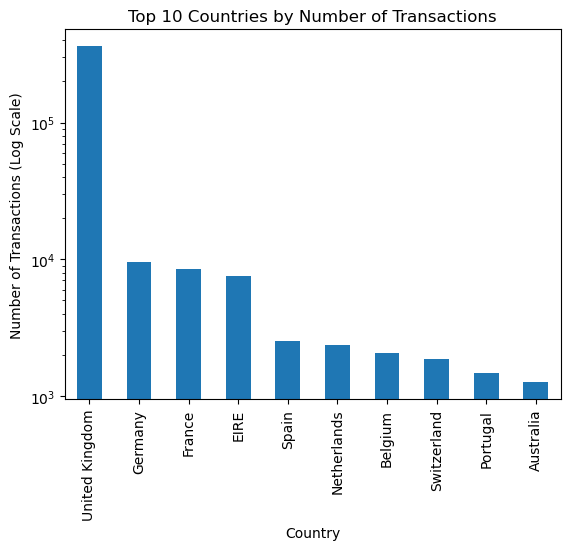

In [192]:
top_countries = df['Country'].value_counts().head(10)
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Country')
plt.ylabel('Number of Transactions (Log Scale)')
plt.yscale('log')
plt.show()

creating month column

In [193]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


In [194]:
df['Month'].nunique()

13

Aggregate revenue

In [195]:
monthly_sales = df.groupby('Month')['Revenue'].sum()
monthly_sales

Month
2010-12     554604.020
2011-01     475074.380
2011-02     436546.150
2011-03     579964.610
2011-04     426047.851
2011-05     648251.080
2011-06     608013.160
2011-07     574238.481
2011-08     616368.000
2011-09     931440.372
2011-10     974603.590
2011-11    1132407.740
2011-12     342506.380
Freq: M, Name: Revenue, dtype: float64

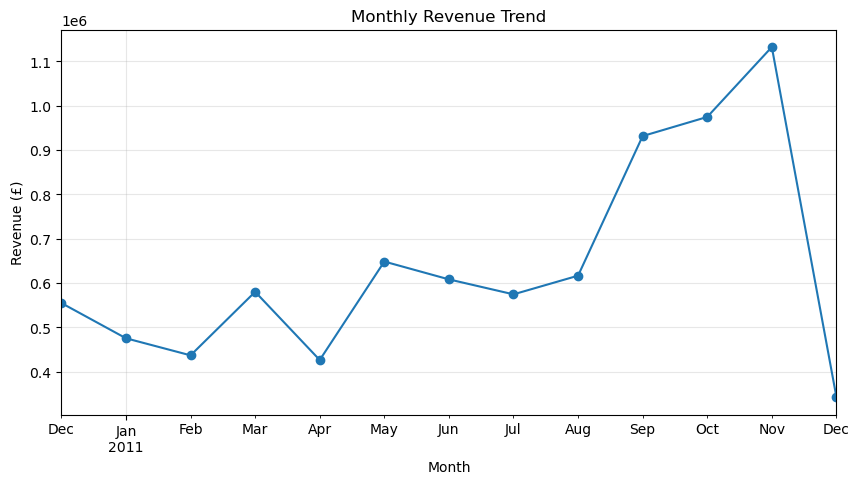

In [196]:

monthly_sales.plot(figsize=(10,5), marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.grid(True, alpha=0.3)
plt.show()

removing cancelled invoices

In [197]:
#cancelled invoices start with c
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

removing negative quantities

In [198]:
df = df[df['Quantity'] > 0]

removing negative prices

In [199]:
df = df[df['UnitPrice'] > 0]

In [200]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


Finding MAX DATE

Reason: Recency values start from 1 instead of 0, Avoids having customers with 0 days recency.

In [201]:
max_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(max_date)

2011-12-10 12:50:00


Selected 1st Sep 2011 as dividing date, (before this date = Past data)(After this date = Future Data)

Take all trasncations before sep 2011 and store in Train_period, used to create customer behavior fetures

transactions after sep 2011 stored in future_period, used to determine whether customr churn or not

In [202]:
cutoff_date = pd.Timestamp('2011-09-01')
train_period = df[df['InvoiceDate'] < cutoff_date]
future_period = df[df['InvoiceDate'] >= cutoff_date]

In [203]:
print(train_period.shape)
print(future_period.shape)

(226467, 10)
(171417, 10)


In [204]:
train_period['Revenue'] = (train_period['Quantity']*train_period['UnitPrice'])

find the last date in training period, used for recency calculation

In [205]:
snapshot_date = train_period['InvoiceDate'].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-09-01 17:16:00


In [206]:
recency = train_period.groupby('CustomerID')['InvoiceDate'].max()
recency = (snapshot_date - recency).dt.days

In [207]:
frequency = train_period.groupby('CustomerID')['InvoiceNo'].nunique()

In [208]:
monetary = train_period.groupby('CustomerID')['Revenue'].sum()

In [209]:
rfm = pd.DataFrame()
rfm['Recency'] = recency
rfm['Frequency'] = frequency
rfm['Monetary'] = monetary
rfm.reset_index(inplace=True) #to get customer id as normal column
print(rfm.head(5))

   CustomerID  Recency  Frequency  Monetary
0       12346      226          1  77183.60
1       12347       30          5   2790.86
2       12348      149          3   1487.24
3       12350      211          1    334.40
4       12352      163          5   1561.81


In [210]:
#find customers who purchased after sep 2011
active_customers = future_period['CustomerID'].unique()

In [212]:
#if customer purchase again churn =0(not churning)else chrun=1(churned)
rfm['Churn'] = np.where(rfm['CustomerID'].isin(active_customers),0,1)
print(rfm)

      CustomerID  Recency  Frequency  Monetary  Churn
0          12346      226          1  77183.60      1
1          12347       30          5   2790.86      0
2          12348      149          3   1487.24      0
3          12350      211          1    334.40      1
4          12352      163          5   1561.81      0
...          ...      ...        ...       ...    ...
3312       18280      178          1    180.60      1
3313       18281       81          1     80.82      1
3314       18282       27          1    100.21      0
3315       18283       49          9    985.77      0
3316       18287      102          1    765.28      0

[3317 rows x 5 columns]


In [214]:
rfm['Churn'].value_counts()

Churn
0    1952
1    1365
Name: count, dtype: int64

In [215]:
features = rfm[['Recency','Frequency','Monetary']]
scaler = StandardScaler() #create scaler
scaled_features = scaler.fit_transform(features) #scaling converts everything to similar scale

K-Means clustering was used to segment customers based on purchasing behaviour.

In [216]:
kmeans = KMeans(n_clusters=4,random_state=42) #create 4 customer groups
rfm['Segment'] = kmeans.fit_predict(scaled_features) #automactically groups similar customers

In [218]:
X = rfm[['Recency','Frequency','Monetary']]
Y = rfm['Churn']

In [235]:
print(rfm)

      CustomerID  Recency  Frequency  Monetary  Churn  Segment
0          12346      226          1  77183.60      1        3
1          12347       30          5   2790.86      0        0
2          12348      149          3   1487.24      0        1
3          12350      211          1    334.40      1        1
4          12352      163          5   1561.81      0        1
...          ...      ...        ...       ...    ...      ...
3312       18280      178          1    180.60      1        1
3313       18281       81          1     80.82      1        0
3314       18282       27          1    100.21      0        0
3315       18283       49          9    985.77      0        2
3316       18287      102          1    765.28      0        0

[3317 rows x 6 columns]


In [222]:
segment_counts = pd.DataFrame({'Segment': segment_counts.index,'Customer_Count': segment_counts.values})
print(segment_counts)

   Segment  Customer_Count
0        0            1994
1        1            1005
2        2             296
3        3              22


In [257]:
for segment in sorted(rfm['Segment'].unique()):
    print(f"\nSegment {segment}")
    print(rfm[rfm['Segment'] == segment]['Churn'].value_counts())


Segment 0
Churn
0    1270
1     724
Name: count, dtype: int64

Segment 1
Churn
1    624
0    381
Name: count, dtype: int64

Segment 2
Churn
0    280
1     16
Name: count, dtype: int64

Segment 3
Churn
0    21
1     1
Name: count, dtype: int64


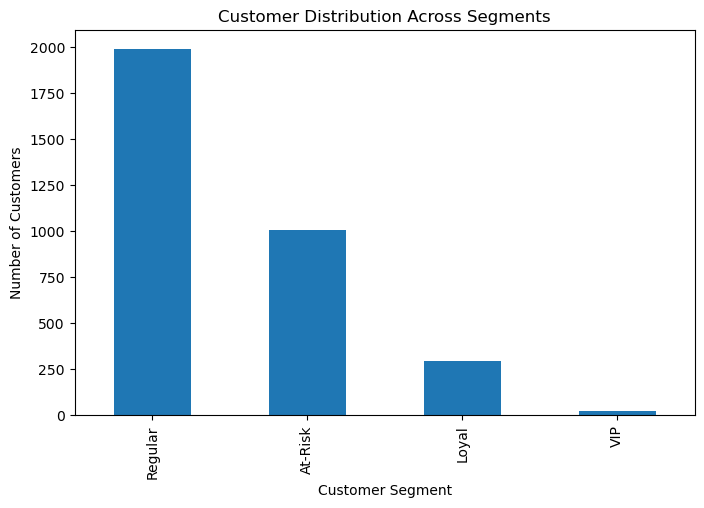

In [240]:
segment_labelling = {0: 'Regular',1: 'At-Risk',2: 'Loyal',3: 'VIP'}
plot_data = segment_counts.copy()
plot_data.index = plot_data.index.map(segment_labelling)
plot_data['Customer_Count'].plot(kind='bar',legend=False,figsize=(8,5))
plt.title('Customer Distribution Across Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.show()

In [241]:
#The data was split into training and testing sets to evaluate model generalization.
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [242]:
#create random forest, traing global model using rfm features
rf_global = RandomForestClassifier(random_state=42)
rf_global.fit(X_train,Y_train)

RandomForestClassifier(random_state=42)

In [250]:
from sklearn.metrics import (accuracy_score,f1_score,roc_auc_score)
global_predict = rf_global.predict(X_test) #Predict churn for unseen customers.
global_acc = accuracy_score(Y_test,global_predict) #How many predictions were correct.
global_f1 = f1_score(Y_test,global_predict) #How clearly model identifies churn customers.
global_auc = roc_auc_score(Y_test,rf_global.predict_proba(X_test)[:,1]) #Measures how well model separates:

print(global_acc)
print(global_f1)
print(global_auc)

0.6445783132530121
0.5461538461538461
0.7057184077644436


In [270]:
comparison_results = []

In [271]:
for segment in sorted(rfm['Segment'].unique()):
    segment_data = rfm[rfm['Segment'] == segment]
    if len(segment_data) < 50:
        print(f"Skipping Segment {segment} - less records")
        continue
    
    X_seg = segment_data[['Recency','Frequency','Monetary']]
    Y_seg = segment_data['Churn']
    
    X_train_seg, X_test_seg, Y_train_seg, Y_test_seg = train_test_split(X_seg,Y_seg,test_size=0.2,random_state=42,stratify=Y_seg)

    rf_segment = RandomForestClassifier(random_state=42)
    rf_segment.fit(X_train_seg, Y_train_seg)
    predict_segment = rf_segment.predict(X_test_seg)
    segment_acc = accuracy_score(Y_test_seg,predict_segment)

    segment_f1 = f1_score(Y_test_seg,predict_segment)
    segment_auc = roc_auc_score(Y_test_seg,rf_segment.predict_proba(X_test_seg)[:,1])
    comparison_results.append([segment,global_acc,segment_acc,global_f1,segment_f1,global_auc,segment_auc])

Skipping Segment 3 - less records


In [273]:
comparison_df = pd.DataFrame(
    comparison_results,
    columns=[
        'Segment',
        'Global Accuracy',
        'Segment Accuracy',
        'Global F1',
        'Segment F1',
        'Global AUC',
        'Segment AUC'
    ]
)

comparison_df

,Segment,Global Accuracy,Segment Accuracy,Global F1,Segment F1,Global AUC,Segment AUC
0,0,0.644578,0.636591,0.546154,0.431373,0.705718,0.678061
1,1,0.644578,0.616915,0.546154,0.715867,0.705718,0.601421
2,2,0.644578,0.950000,0.546154,0.400000,0.705718,0.698830


In [274]:
comparison_df['Accuracy Improvement'] = (comparison_df['Segment Accuracy'] -comparison_df['Global Accuracy'])
comparison_df['F1 Improvement'] = (comparison_df['Segment F1']-comparison_df['Global F1'])
comparison_df['AUC Improvement'] = (comparison_df['Segment AUC']- comparison_df['Global AUC'])
comparison_df

,Segment,Global Accuracy,Segment Accuracy,Global F1,Segment F1,Global AUC,Segment AUC,Accuracy Improvement,F1 Improvement,AUC Improvement
0,0,0.644578,0.636591,0.546154,0.431373,0.705718,0.678061,-0.007987,-0.114781,-0.027657
1,1,0.644578,0.616915,0.546154,0.715867,0.705718,0.601421,-0.027663,0.169713,-0.104297
2,2,0.644578,0.950000,0.546154,0.400000,0.705718,0.698830,0.305422,-0.146154,-0.006888
